**AnoGanを試してみました。**

**皆様のご参考になれれば幸いです。**

In [1]:
from keras.models import Model
from keras.layers import Input, Dense, Conv2D, BatchNormalization, LeakyReLU, Reshape, Conv2DTranspose
from keras.layers.core import Activation

In [2]:
class Generator(object):
    def __init__(self, input_dim, image_shape):
        INITIAL_CHANNELS = 256
        INITIAL_SIZE = 64

        inputs = Input((input_dim,))
        fc1 = Dense(input_dim=input_dim, units=INITIAL_CHANNELS * INITIAL_SIZE * INITIAL_SIZE)(inputs)
        fc1 = BatchNormalization()(fc1)
        fc1 = LeakyReLU(0.2)(fc1)
        fc2 = Reshape((INITIAL_SIZE, INITIAL_SIZE, INITIAL_CHANNELS), input_shape=(INITIAL_CHANNELS * INITIAL_SIZE * INITIAL_SIZE,))(fc1)
        up1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(fc2)
        conv1 = Conv2D(64, (3, 3), padding='same')(up1)
        conv1 = BatchNormalization()(conv1)
        conv1 = Activation('relu')(conv1)
        up2 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv1)
        conv2 = Conv2D(image_shape[2], (5, 5), padding='same')(up2)
        outputs = Activation('tanh')(conv2)

        self.model = Model(inputs=[inputs], outputs=[outputs])

    def get_model(self):
        return self.model

In [3]:
from keras.models import Model
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, LeakyReLU, Flatten
from keras.layers.core import Activation

class Discriminator(object):
    def __init__(self, input_shape):
        inputs = Input(input_shape)
        conv1 = Conv2D(64, (5, 5), padding='same')(inputs)
        conv1 = LeakyReLU(0.2)(conv1)
        pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)
        conv2 = Conv2D(128, (5, 5), padding='same')(pool1)
        conv2 = LeakyReLU(0.2)(conv2)
        pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)
        fc1 = Flatten()(pool2)
        fc1 = Dense(1)(fc1)
        outputs = Activation('sigmoid')(fc1)

        self.model = Model(inputs=[inputs], outputs=[outputs])

    def get_model(self):
        return self.model

In [4]:
import math, cv2
import numpy as np

from keras.models import Model, Sequential
from keras.utils. generic_utils import Progbar

class DCGAN(object):
    def __init__(self, input_dim, image_shape):
        self.input_dim = input_dim
        self.d = Discriminator(image_shape).get_model()
        self.g = Generator(input_dim, image_shape).get_model()

    def compile(self, g_optim, d_optim):
        self.d.trainable = False
        self.dcgan = Sequential([self.g, self.d])
        self.dcgan.compile(loss='binary_crossentropy', optimizer=g_optim)
        self.d.trainable = True
        self.d.compile(loss='binary_crossentropy', optimizer=d_optim)

    def train(self, epochs, batch_size, X_train):
        g_losses = []
        d_losses = []
        for epoch in range(epochs):
            np.random.shuffle(X_train)
            n_iter = X_train.shape[0] // batch_size
            progress_bar = Progbar(target=n_iter)
            for index in range(n_iter):
                # create random noise -> N latent vectors
                noise = np.random.uniform(-1, 1, size=(batch_size, self.input_dim))

                # load real data & generate fake data
                image_batch = X_train[index * batch_size:(index + 1) * batch_size]
                for i in range(batch_size):
                    if np.random.random() > 0.5:
                        image_batch[i] = np.fliplr(image_batch[i])
                    if np.random.random() > 0.5:
                        image_batch[i] = np.flipud(image_batch[i])
                generated_images = self.g.predict(noise, verbose=0)

                # attach label for training discriminator
                X = np.concatenate((image_batch, generated_images))
                y = np.array([1] * batch_size + [0] * batch_size)

                # training discriminator
                d_loss = self.d.train_on_batch(X, y)

                # training generator
                g_loss = self.dcgan.train_on_batch(noise, np.array([1] * batch_size))

                progress_bar.update(index, values=[('g', g_loss), ('d', d_loss)])
            g_losses.append(g_loss)
            d_losses.append(d_loss)
            if (epoch+1)%10 == 0:
                image = self.combine_images(generated_images)
                #image = (image + 1) / 2.0 * 255.0
                cv2.imwrite('./result/' + str(epoch) + ".png", image)
            print('\nEpoch' + str(epoch) + " end")

            # save weights for each epoch
            if (epoch+1)%5 == 0:
                self.g.save_weights('./generator_' + str(epoch) + '.h5', True)
                self.d.save_weights('./discriminator_' + str(epoch) + '.h5', True)
        return g_losses, d_losses

    def load_weights(self, g_weight, d_weight):
        self.g.load_weights(g_weight)
        self.d.load_weights(d_weight)

    def combine_images(self, generated_images):
        num = generated_images.shape[0]
        width = int(math.sqrt(num))
        height = int(math.ceil(float(num) / width))
        shape = generated_images.shape[1:4]
        image = np.zeros((height * shape[0], width * shape[1], shape[2]),
                         dtype=generated_images.dtype)
        for index, img in enumerate(generated_images):
            i = int(index / width)
            j = index % width
            image[i * shape[0]:(i + 1) * shape[0], j * shape[1]:(j + 1) * shape[1], :] = img[:, :, :]
        return image

In [5]:
ComputeLB = False

import os, gc, zipfile
import numpy as np, pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import librosa 
import cv2

PATH='../input/hah-data-science-challenge/'

In [6]:
# change wave data to mel-stft
def calculate_melsp(x, n_fft=1024, hop_length=128):
    stft = np.abs(librosa.stft(x, n_fft=n_fft, hop_length=hop_length))**2
    log_stft = librosa.power_to_db(stft)
    melsp = librosa.feature.melspectrogram(S=log_stft,n_mels=128)
    return melsp

In [7]:
train = pd.read_csv("../input/hah-data-science-challenge/train.csv")
smpl_sub = pd.read_csv("../input/hah-data-science-challenge/test.csv")

Target=0のみを学習させます！

In [8]:
train = train[train.Target==0]
train['Target']=train['Target'].astype('int64')
train=train.reset_index()

音声データをメルスペクトグラムに変換します。

In [9]:
# CREATE RANDOMLY CROPPED IMAGES
x_train=np.zeros([len(train),256,256,1])
for i in range(len(train)):
    y, sr = librosa.core.load(PATH+'/train/train/'+train["ファイル"].values[i],sr=None)
    y = librosa.util.normalize(y)
    melsp = calculate_melsp(y)
    img = melsp
    img = cv2.resize(img,(256,256))
    img = img.reshape(256,256,1)
    img = (img-img.min())/(img.max()-img.min())
    x_train[i] = img

DCGANを使って学習させます。

In [10]:
from keras.optimizers import Adam

batch_size = 16
epochs = 100
input_dim = 30
g_optim = Adam(lr=0.0001, beta_1=0.5, beta_2=0.9)
d_optim = Adam(lr=0.0001, beta_1=0.5, beta_2=0.9)

### 0. prepare data
input_shape = x_train[0].shape

### 1. train generator & discriminator
dcgan = DCGAN(input_dim, input_shape)
dcgan.compile(g_optim, d_optim)
g_losses, d_losses = dcgan.train(epochs, batch_size, x_train)
with open('loss.csv', 'w') as f:
    for g_loss, d_loss in zip(g_losses, d_losses):
        f.write(str(g_loss) + ',' + str(d_loss) + '\n')

23/24 [===========================>..] - ETA: 0s - g: 0.0391 - d: 0.2709
Epoch0 end
23/24 [===========================>..] - ETA: 0s - g: 7.1196e-09 - d: 0.0103
Epoch1 end
23/24 [===========================>..] - ETA: 0s - g: 5.1495e-19 - d: 0.0022
Epoch2 end
23/24 [===========================>..] - ETA: 0s - g: 2.2678e-23 - d: 4.8954e-04
Epoch3 end
23/24 [===========================>..] - ETA: 0s - g: 1.1757e-28 - d: 1.8467e-04
Epoch4 end
23/24 [===========================>..] - ETA: 0s - g: 2.9941e-30 - d: 1.6547e-04
Epoch5 end
23/24 [===========================>..] - ETA: 0s - g: 6.1402e-29 - d: 1.5672e-05
Epoch6 end
23/24 [===========================>..] - ETA: 0s - g: 1.6226e-22 - d: 2.5162e-05
Epoch7 end
23/24 [===========================>..] - ETA: 0s - g: 1.4070e-15 - d: 1.9763e-05
Epoch8 end
23/24 [===========================>..] - ETA: 0s - g: 1.0329e-11 - d: 4.2908e-06
Epoch9 end
23/24 [===========================>..] - ETA: 0s - g: 1.0281e-08 - d: 1.3622e-05
Epoch10 end
23/

In [11]:
import numpy as np
from keras.models import Model
from keras.layers import Input, Dense
import keras.backend as K

def sum_of_residual(y_true, y_pred):
    return K.sum(K.abs(y_true - y_pred))

class ANOGAN(object):
    def __init__(self, input_dim, g):
        self.input_dim = input_dim
        self.g = g
        g.trainable = False
        # Input layer cann't be trained. Add new layer as same size & same distribution
        anogan_in = Input(shape=(input_dim,))
        g_in = Dense((input_dim), activation='tanh', trainable=True)(anogan_in)
        g_out = g(g_in)
        self.model = Model(inputs=anogan_in, outputs=g_out)
        self.model_weight = None

    def compile(self, optim):
        self.model.compile(loss=sum_of_residual, optimizer=optim)
        K.set_learning_phase(0)

    def compute_anomaly_score(self, x, iterations=300):
        z = np.random.uniform(-1, 1, size=(1, self.input_dim))

        # learning for changing latent
        loss = self.model.fit(z, x, batch_size=1, epochs=iterations, verbose=0)
        loss = loss.history['loss'][-1]
        similar_data = self.model.predict_on_batch(z)

        return loss, similar_data

AnoGanを使い、異常値スコアを算出します。

In [12]:
iterations = 100
input_dim = 30
anogan_optim = Adam(lr=0.001, amsgrad=True)

    ### 0. prepare data
input_shape = x_train[0].shape

### 1. train generator & discriminator
dcgan = DCGAN(input_dim, input_shape)
dcgan.load_weights('./generator_44.h5', './discriminator_44.h5')

img_ge = np.zeros([len(x_train),256,256,1])
anomaly_score_log = np.zeros(len(x_train))
for i, test_img in enumerate(x_train):
    test_img = test_img[np.newaxis,:,:,:]
    anogan = ANOGAN(input_dim, dcgan.g)
    anogan.compile(anogan_optim)
    anomaly_score, generated_img = anogan.compute_anomaly_score(test_img, iterations)
    #generated_img = denormalize(generated_img)
    img_ge[i] = generated_img
    anomaly_score_log[i] = anomaly_score
    #imgs = np.concatenate((test_img[0], generated_img[0]), axis=1)
    #cv2.imwrite('./predict' + os.sep + str(int(anomaly_score)) + '_' + str(i) + '.png', imgs)
    #print(str(i) + ' %.2f'%anomaly_score)
    with open('scores.txt', 'a') as f:
        f.write(str(anomaly_score) + '\n')

/opt/conda/lib/python3.7/site-packages/tensorflow/python/keras/backend.py:434: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn('`tf.keras.backend.set_learning_phase` is deprecated and '


可視化してみます！

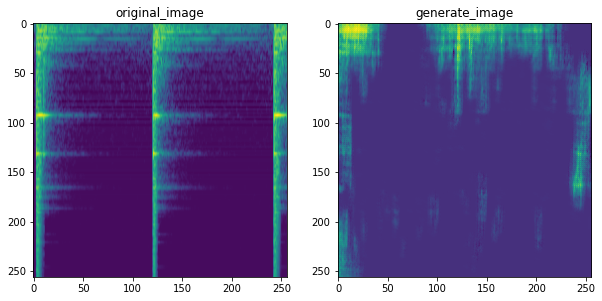

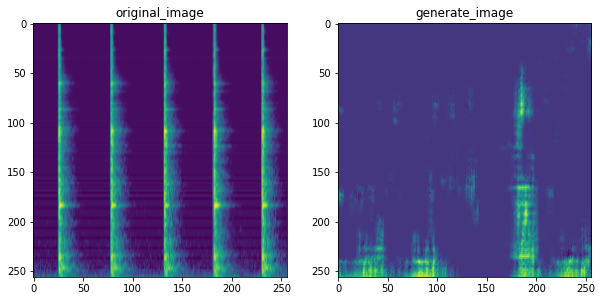

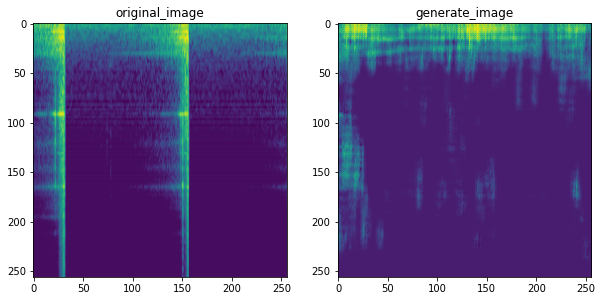

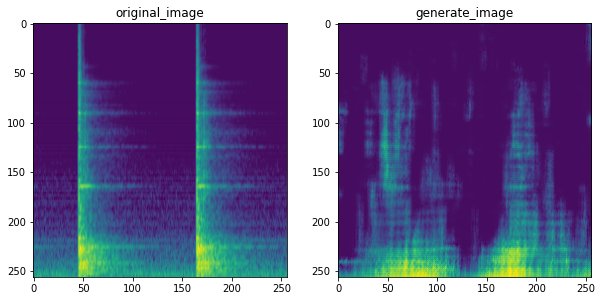

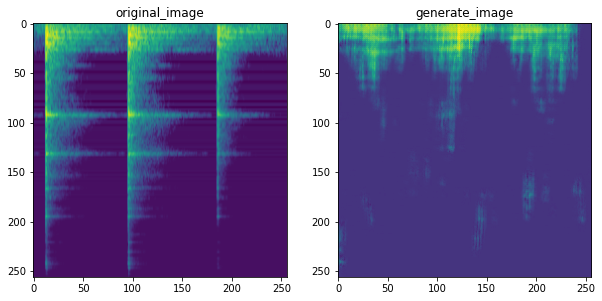

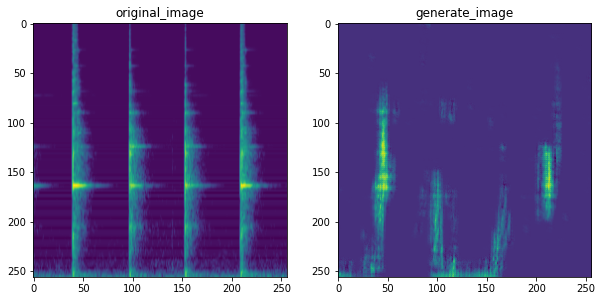

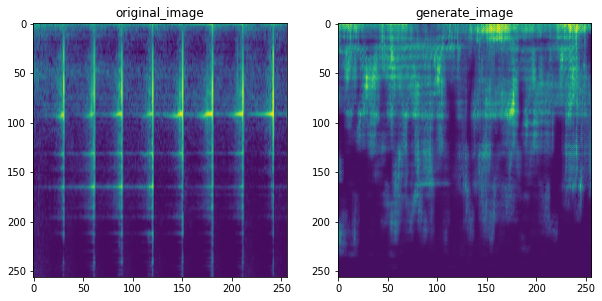

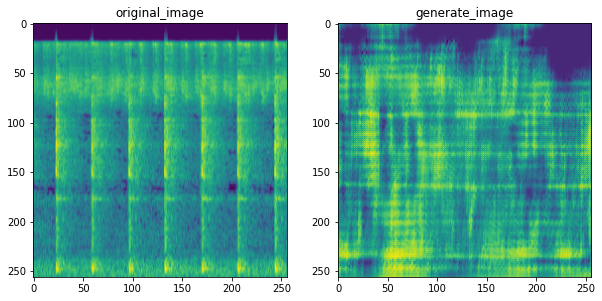

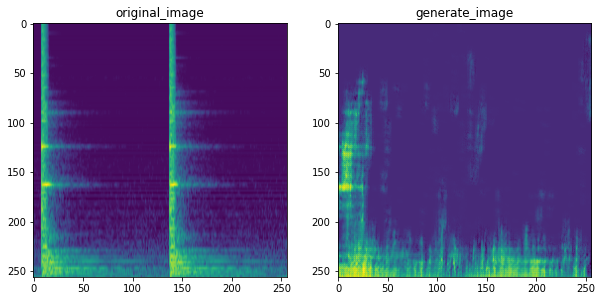

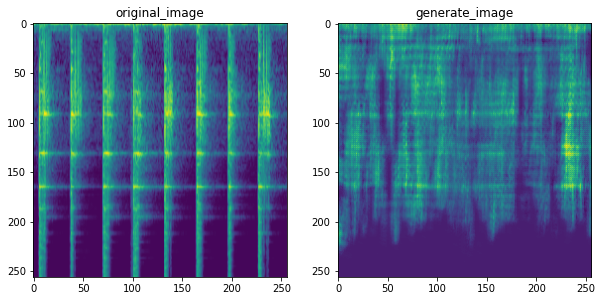

In [13]:
for i in range(10):
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(x_train[i,:,:,0])
    plt.title('original_image')
    plt.subplot(1,2,2)
    plt.imshow(img_ge[i,:,:,0])
    plt.title('generate_image')
    plt.show()

異常値スコアの頻度を確認します。

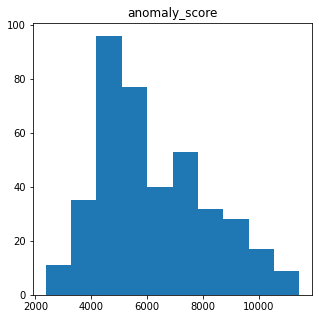

In [14]:
plt.figure(figsize=(5,5))
plt.hist(anomaly_score_log)
plt.title('anomaly_score')
plt.show()

次にTarget=1を確認していきます。

In [15]:
train = pd.read_csv("../input/hah-data-science-challenge/train.csv")

train = train[train.Target==1]
train['Target']=train['Target'].astype('int64')
train=train.reset_index()

# CREATE RANDOMLY CROPPED IMAGES
x_train=np.zeros([len(train),256,256,1])
for i in range(len(train)):
    y, sr = librosa.core.load(PATH+'/train/train/'+train["ファイル"].values[i],sr=None)
    y = librosa.util.normalize(y)
    melsp = calculate_melsp(y)
    img = melsp
    img = cv2.resize(img,(256,256))
    img = img.reshape(256,256,1)
    img = (img-img.min())/(img.max()-img.min())
    x_train[i] = img

iterations = 100
input_dim = 30
anogan_optim = Adam(lr=0.001, amsgrad=True)

    ### 0. prepare data
input_shape = x_train[0].shape

### 1. train generator & discriminator
dcgan = DCGAN(input_dim, input_shape)
dcgan.load_weights('./generator_44.h5', './discriminator_44.h5')

img_ge = np.zeros([len(x_train),256,256,1])
anomaly_score_log2 = np.zeros(len(x_train))
for i, test_img in enumerate(x_train):
    test_img = test_img[np.newaxis,:,:,:]
    anogan = ANOGAN(input_dim, dcgan.g)
    anogan.compile(anogan_optim)
    anomaly_score, generated_img = anogan.compute_anomaly_score(test_img, iterations)
    #generated_img = denormalize(generated_img)
    img_ge[i] = generated_img
    anomaly_score_log2[i] = anomaly_score
    #imgs = np.concatenate((test_img[0], generated_img[0]), axis=1)
    #cv2.imwrite('./predict' + os.sep + str(int(anomaly_score)) + '_' + str(i) + '.png', imgs)
    #print(str(i) + ' %.2f'%anomaly_score)
    with open('scores.txt', 'a') as f:
        f.write(str(anomaly_score) + '\n')

/opt/conda/lib/python3.7/site-packages/tensorflow/python/keras/backend.py:434: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn('`tf.keras.backend.set_learning_phase` is deprecated and '


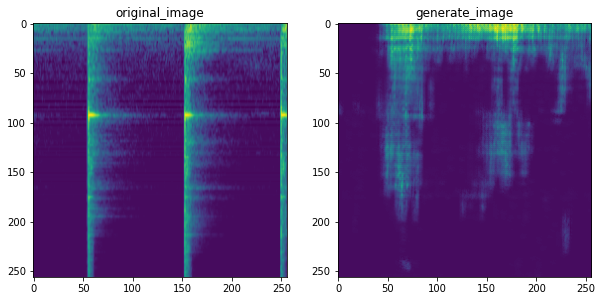

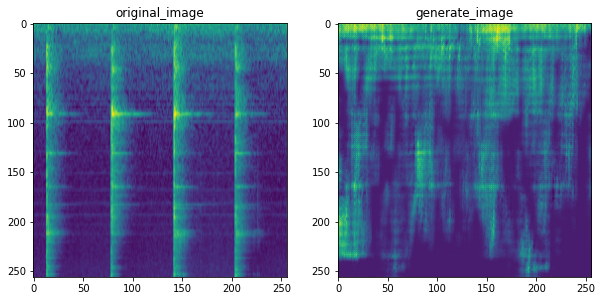

In [16]:
for i in range(2):
    plt.figure(figsize=(10,10))
    plt.subplot(1,2,1)
    plt.imshow(x_train[i,:,:,0])
    plt.title('original_image')
    plt.subplot(1,2,2)
    plt.imshow(img_ge[i,:,:,0])
    plt.title('generate_image')
    plt.show()

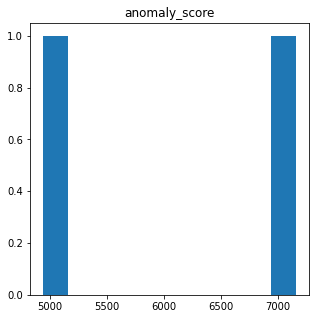

In [17]:
plt.figure(figsize=(5,5))
plt.hist(anomaly_score_log2)
plt.title('anomaly_score')
plt.show()

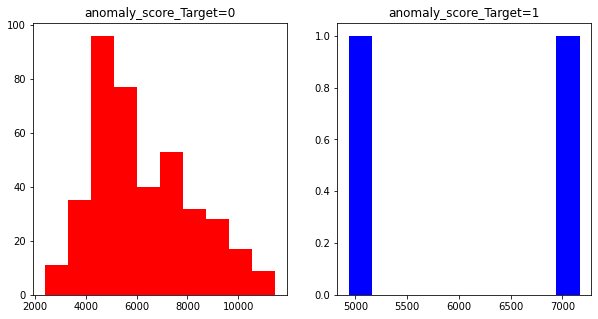

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(anomaly_score_log,color='red')
plt.title('anomaly_score_Target=0')
plt.subplot(1,2,2)
plt.hist(anomaly_score_log2,color='blue')
plt.title('anomaly_score_Target=1')
plt.show()

**所感**

・Ganの学習が難しいせいか、Target=0でさえも上手く画像が生成できていないように感じます。

・異常値スコアを算出したが、現状ではTarget=0とTarget=1の区別が難しいです。（何か工夫が必要？）
